<a href="https://colab.research.google.com/github/rajen1kgthb/UCI-X427.05/blob/main/Module4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. DATA VALIDATION AUDIT
Original number of rows: 184
Date range: 2025-06-18 through 2026-07-31

Missing values by column:
Date               0
DayOfWeek          0
CompletedAppts     0
GrossProduction    0
dtype: int64

Duplicate rows: 0

Date/weekday mismatches: 0

2. OPERATING-DAY FILTER

Original weekday counts:
DayOfWeek
Wednesday    57
Friday       54
Monday       54
Saturday     11
Tuesday       7
Thursday      1
Name: count, dtype: int64

Regular M/W/F rows retained: 165
Nonstandard rows excluded: 19

Excluded rows by weekday:
DayOfWeek
Saturday    11
Tuesday      7
Thursday     1
Name: count, dtype: int64

3. DESCRIPTIVE STATISTICS

Numerical summary:
       CompletedAppts  GrossProduction
count          165.00           165.00
mean             9.99          3861.19
std              3.73          1956.75
min              1.00           940.00
25%              8.00          2639.00
50%             10.00          3483.00
75%             12.00          4785.00
max             27.

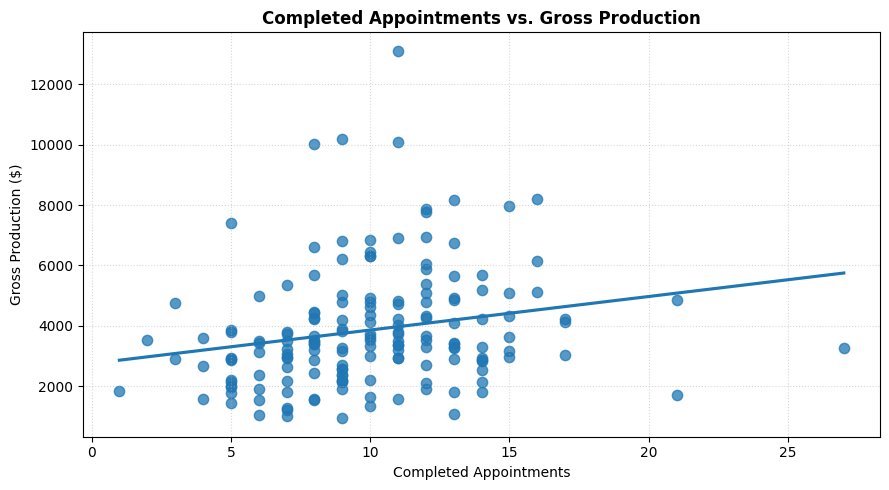

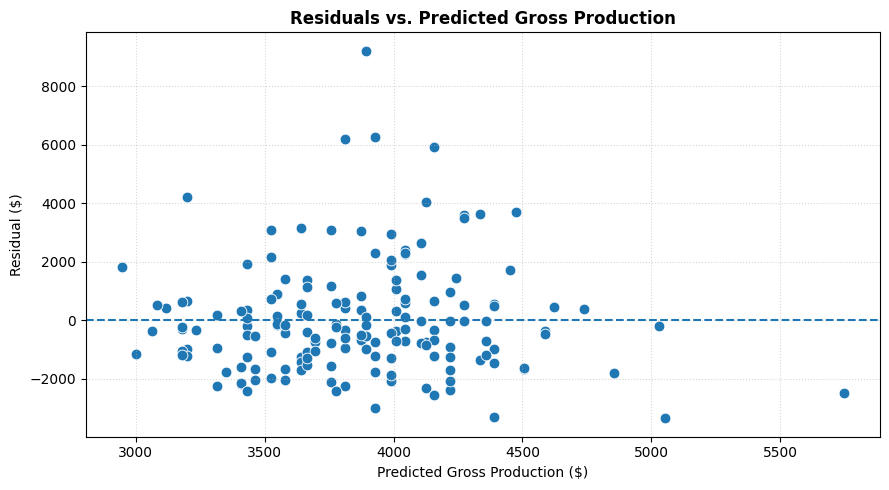

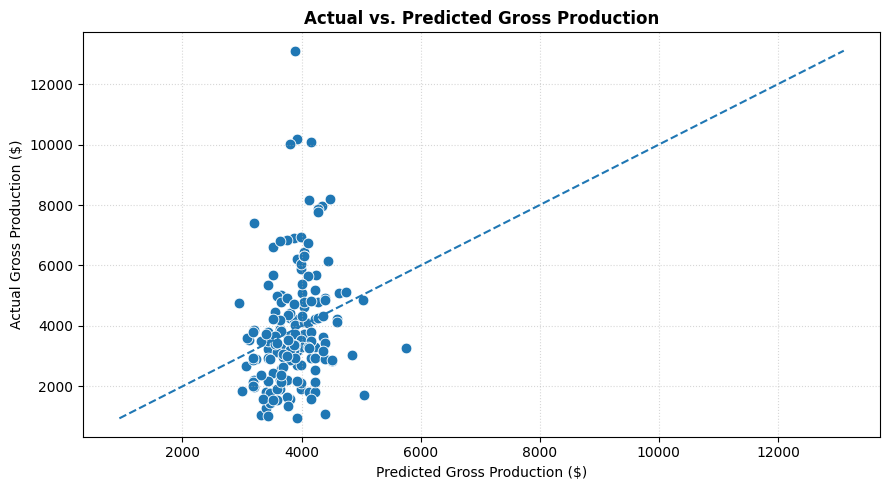

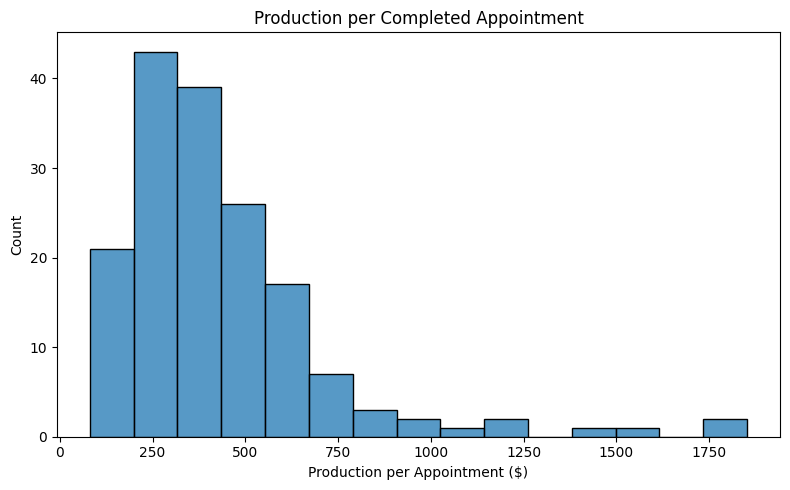


Analysis complete.
Generated files: regression_coefficients.csv and dental_production_model_results.csv


In [7]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

# 1. Embedded Static Data
raw_data = """Date\tDayOfWeek\tCompletedAppts\tGrossProduction
2025-06-18\tWednesday\t10\t4617.00
2025-06-20\tFriday\t9\t3904.00
2025-06-21\tSaturday\t2\t1313.00
2025-06-23\tMonday\t9\t2563.00
2025-06-25\tWednesday\t10\t3319.00
2025-06-27\tFriday\t9\t2375.00
2025-06-30\tMonday\t5\t3847.00
2025-07-02\tWednesday\t9\t2720.00
2025-07-03\tThursday\t1\t547.00
2025-07-07\tMonday\t14\t5672.00
2025-07-09\tWednesday\t9\t3176.00
2025-07-11\tFriday\t12\t5887.00
2025-07-12\tSaturday\t1\t5739.00
2025-07-14\tMonday\t9\t2582.00
2025-07-16\tWednesday\t2\t3520.00
2025-07-18\tFriday\t12\t2708.00
2025-07-21\tMonday\t12\t3652.00
2025-07-23\tWednesday\t9\t10182.00
2025-07-25\tFriday\t8\t2428.00
2025-07-28\tMonday\t9\t3273.00
2025-07-30\tWednesday\t15\t5091.00
2025-08-04\tMonday\t17\t4234.00
2025-08-05\tTuesday\t3\t584.00
2025-08-06\tWednesday\t9\t940.00
2025-08-08\tFriday\t7\t1215.00
2025-08-11\tMonday\t8\t3399.00
2025-08-13\tWednesday\t8\t4245.00
2025-08-15\tFriday\t11\t4211.00
2025-08-18\tMonday\t7\t3231.00
2025-08-20\tWednesday\t9\t6212.00
2025-08-22\tFriday\t9\t2208.00
2025-08-25\tMonday\t8\t4455.00
2025-08-27\tWednesday\t8\t1573.00
2025-08-29\tFriday\t11\t6916.00
2025-09-03\tWednesday\t10\t3739.00
2025-09-05\tFriday\t7\t1825.00
2025-09-08\tMonday\t10\t3646.00
2025-09-09\tTuesday\t2\t1650.00
2025-09-10\tWednesday\t12\t4798.00
2025-09-12\tFriday\t4\t2681.00
2025-09-15\tMonday\t11\t4018.00
2025-09-17\tWednesday\t10\t4137.00
2025-09-19\tFriday\t13\t4093.00
2025-09-22\tMonday\t12\t4325.00
2025-09-24\tWednesday\t8\t3492.00
2025-09-26\tFriday\t14\t4211.00
2025-09-29\tMonday\t5\t7418.00
2025-10-01\tWednesday\t6\t3134.00
2025-10-03\tFriday\t15\t7962.00
2025-10-06\tMonday\t7\t3788.00
2025-10-08\tWednesday\t8\t3495.00
2025-10-10\tFriday\t14\t3298.00
2025-10-13\tMonday\t13\t3396.00
2025-10-15\tWednesday\t13\t4929.00
2025-10-17\tFriday\t10\t2203.00
2025-10-20\tMonday\t11\t3721.00
2025-10-22\tWednesday\t8\t2878.00
2025-10-24\tFriday\t10\t6826.00
2025-10-27\tMonday\t12\t5088.00
2025-10-29\tWednesday\t12\t7877.00
2025-10-31\tFriday\t12\t1926.00
2025-11-03\tMonday\t13\t1806.00
2025-11-05\tWednesday\t3\t2890.00
2025-11-07\tFriday\t12\t6041.00
2025-11-08\tSaturday\t3\t940.00
2025-11-10\tMonday\t17\t4115.00
2025-11-12\tWednesday\t12\t7758.00
2025-11-14\tFriday\t15\t2964.00
2025-11-17\tMonday\t7\t3500.00
2025-11-19\tWednesday\t10\t6454.00
2025-11-21\tFriday\t14\t1827.00
2025-11-24\tMonday\t13\t8173.00
2025-11-26\tWednesday\t8\t4439.00
2025-12-01\tMonday\t9\t3838.00
2025-12-02\tTuesday\t3\t1168.00
2025-12-03\tWednesday\t13\t1071.00
2025-12-05\tFriday\t13\t5658.00
2025-12-08\tMonday\t11\t13106.00
2025-12-10\tWednesday\t14\t2830.00
2025-12-12\tFriday\t14\t2154.00
2025-12-13\tSaturday\t5\t3462.00
2025-12-15\tMonday\t21\t1700.00
2025-12-17\tWednesday\t16\t5137.00
2025-12-19\tFriday\t21\t4846.00
2025-12-20\tSaturday\t4\t1404.00
2025-12-22\tMonday\t27\t3278.00
2025-12-23\tTuesday\t8\t1682.00
2025-12-30\tTuesday\t1\t2401.00
2026-01-02\tFriday\t12\t3541.00
2026-01-05\tMonday\t16\t8188.00
2026-01-06\tTuesday\t8\t1715.00
2026-01-07\tWednesday\t11\t2943.00
2026-01-09\tFriday\t12\t2105.00
2026-01-12\tMonday\t12\t3309.00
2026-01-14\tWednesday\t9\t2169.00
2026-01-16\tFriday\t9\t1925.00
2026-01-19\tMonday\t10\t4353.00
2026-01-21\tWednesday\t7\t2962.00
2026-01-23\tFriday\t16\t6154.40
2026-01-26\tMonday\t9\t5023.00
2026-01-28\tWednesday\t5\t1787.00
2026-01-30\tFriday\t14\t2949.00
2026-02-02\tMonday\t5\t2202.00
2026-02-04\tWednesday\t6\t1909.00
2026-02-06\tFriday\t5\t2874.00
2026-02-07\tSaturday\t3\t3294.00
2026-02-09\tMonday\t6\t1061.00
2026-02-11\tWednesday\t1\t1852.00
2026-02-13\tFriday\t11\t3196.00
2026-02-16\tMonday\t4\t3590.00
2026-02-18\tWednesday\t6\t5005.00
2026-02-20\tFriday\t7\t1273.00
2026-02-23\tMonday\t8\t3677.00
2026-02-25\tWednesday\t11\t3812.00
2026-02-27\tFriday\t5\t2945.40
2026-02-28\tSaturday\t2\t652.00
2026-03-02\tMonday\t7\t1025.00
2026-03-04\tWednesday\t11\t3483.00
2026-03-06\tFriday\t10\t1640.05
2026-03-09\tMonday\t11\t3354.00
2026-03-11\tWednesday\t10\t4785.00
2026-03-13\tFriday\t9\t4180.40
2026-03-16\tMonday\t7\t5364.50
2026-03-18\tWednesday\t5\t1435.00
2026-03-20\tFriday\t8\t4239.00
2026-03-21\tSaturday\t1\t3026.00
2026-03-23\tMonday\t6\t3487.00
2026-03-25\tWednesday\t12\t4255.70
2026-03-27\tFriday\t5\t2131.00
2026-03-30\tMonday\t7\t2921.10
2026-04-01\tWednesday\t8\t3196.70
2026-04-03\tFriday\t3\t4756.00
2026-04-06\tMonday\t8\t3415.00
2026-04-08\tWednesday\t7\t2639.00
2026-04-10\tFriday\t7\t3742.00
2026-04-13\tMonday\t9\t2127.15
2026-04-15\tWednesday\t4\t1565.00
2026-04-17\tFriday\t11\t3380.00
2026-04-20\tMonday\t7\t2163.75
2026-04-22\tWednesday\t6\t1535.58
2026-04-24\tFriday\t8\t5676.50
2026-04-27\tMonday\t10\t1355.05
2026-04-29\tWednesday\t11\t1592.90
2026-05-01\tFriday\t5\t3801.70
2026-05-04\tMonday\t9\t2358.40
2026-05-06\tWednesday\t17\t3049.80
2026-05-08\tFriday\t8\t6622.00
2026-05-09\tSaturday\t1\t1864.00
2026-05-11\tMonday\t11\t2925.05
2026-05-13\tWednesday\t5\t2912.80
2026-05-15\tFriday\t8\t1536.05
2026-05-16\tSaturday\t3\t600.00
2026-05-18\tMonday\t9\t4792.40
2026-05-20\tWednesday\t11\t10096.00
2026-05-22\tFriday\t13\t3314.00
2026-05-27\tWednesday\t13\t4865.40
2026-05-29\tFriday\t9\t6797.00
2026-06-01\tMonday\t5\t1989.00
2026-06-03\tWednesday\t10\t6318.20
2026-06-05\tFriday\t5\t1998.00
2026-06-08\tMonday\t6\t2367.00
2026-06-10\tWednesday\t8\t10016.00
2026-06-12\tFriday\t12\t6936.20
2026-06-15\tMonday\t10\t3536.00
2026-06-17\tWednesday\t6\t3422.00
2026-06-24\tWednesday\t13\t2917.70
2026-06-26\tFriday\t14\t2527.10
2026-06-27\tSaturday\t2\t596.00
2026-06-29\tMonday\t15\t3647.50
2026-06-30\tTuesday\t1\t681.00
2026-07-01\tWednesday\t13\t3418.50
2026-07-03\tFriday\t10\t4925.00
2026-07-06\tMonday\t15\t4326.00
2026-07-08\tWednesday\t10\t6327.50
2026-07-10\tFriday\t11\t4711.60
2026-07-13\tMonday\t15\t3171.00
2026-07-15\tWednesday\t7\t3075.20
2026-07-17\tFriday\t14\t5198.89
2026-07-20\tMonday\t12\t5402.00
2026-07-22\tWednesday\t11\t4832.00
2026-07-24\tFriday\t13\t6747.00
2026-07-27\tMonday\t13\t3267.60
2026-07-29\tWednesday\t14\t2859.00
2026-07-31\tFriday\t10\t2996.00"""

# =============================================================
# 2. PARSE AND VALIDATE THE DATA
# =============================================================

df = pd.read_csv(io.StringIO(raw_data), sep="\t")

# Convert columns to appropriate data types
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["CompletedAppts"] = pd.to_numeric(
    df["CompletedAppts"], errors="coerce"
)
df["GrossProduction"] = pd.to_numeric(
    df["GrossProduction"], errors="coerce"
)

print("=" * 70)
print("1. DATA VALIDATION AUDIT")
print("=" * 70)

print(f"Original number of rows: {len(df)}")
print(
    f"Date range: {df['Date'].min().date()} "
    f"through {df['Date'].max().date()}"
)

print("\nMissing values by column:")
print(df.isna().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Verify that the supplied weekday matches the calendar date
df["CalculatedDay"] = df["Date"].dt.day_name()

weekday_mismatches = df[
    df["DayOfWeek"] != df["CalculatedDay"]
]

print(
    f"\nDate/weekday mismatches: "
    f"{len(weekday_mismatches)}"
)

if len(weekday_mismatches) > 0:
    print(
        weekday_mismatches[
            ["Date", "DayOfWeek", "CalculatedDay"]
        ]
    )

# Remove temporary validation column
df = df.drop(columns=["CalculatedDay"])


# =============================================================
# 3. DOCUMENT AND FILTER NONSTANDARD OPERATING DAYS
# =============================================================

print("\n" + "=" * 70)
print("2. OPERATING-DAY FILTER")
print("=" * 70)

print("\nOriginal weekday counts:")
print(df["DayOfWeek"].value_counts())

# Restrict the primary analysis to regular operating days.
# Tuesday, Thursday, and Saturday represent limited or
# nonstandard schedules and have too few observations for
# stable weekday estimates.
standard_days = ["Monday", "Wednesday", "Friday"]

df_filtered = df[
    df["DayOfWeek"].isin(standard_days)
].copy()

excluded_days = df[
    ~df["DayOfWeek"].isin(standard_days)
].copy()

print(f"\nRegular M/W/F rows retained: {len(df_filtered)}")
print(f"Nonstandard rows excluded: {len(excluded_days)}")

print("\nExcluded rows by weekday:")
print(excluded_days["DayOfWeek"].value_counts())


# =============================================================
# 4. DESCRIPTIVE STATISTICS
# =============================================================

print("\n" + "=" * 70)
print("3. DESCRIPTIVE STATISTICS")
print("=" * 70)

print("\nNumerical summary:")
print(
    df_filtered[
        ["CompletedAppts", "GrossProduction"]
    ].describe().round(2)
)

print("\nProduction summary by weekday:")
weekday_summary = (
    df_filtered
    .groupby("DayOfWeek")
    .agg(
        OperatingDays=("Date", "count"),
        AvgCompletedAppts=("CompletedAppts", "mean"),
        AvgProduction=("GrossProduction", "mean"),
        MedianProduction=("GrossProduction", "median"),
        MinProduction=("GrossProduction", "min"),
        MaxProduction=("GrossProduction", "max"),
    )
    .round(2)
)

print(weekday_summary)


# =============================================================
# 5. PREPARE THE REGRESSION VARIABLES
# =============================================================

# Explicitly establish Friday as the reference category.
# Therefore:
#   DayOfWeek_Monday = Monday compared with Friday
#   DayOfWeek_Wednesday = Wednesday compared with Friday
df_filtered["DayOfWeek"] = pd.Categorical(
    df_filtered["DayOfWeek"],
    categories=["Friday", "Monday", "Wednesday"],
    ordered=False,
)

df_encoded = pd.get_dummies(
    df_filtered,
    columns=["DayOfWeek"],
    drop_first=True,
    dtype=int,
)

# Predictor variables
X = df_encoded[
    [
        "CompletedAppts",
        "DayOfWeek_Monday",
        "DayOfWeek_Wednesday",
    ]
].copy()

# Target variable
y = df_encoded["GrossProduction"].copy()

# Add the regression intercept
X_const = sm.add_constant(X)


# =============================================================
# 6. FIT THE ORDINARY LEAST SQUARES REGRESSION MODEL
# =============================================================

model = sm.OLS(y, X_const).fit()

print("\n" + "=" * 70)
print("4. FULL OLS REGRESSION SUMMARY")
print("=" * 70)

print(model.summary())


# =============================================================
# 7. DISPLAY R-SQUARED, COEFFICIENTS, AND SIGNIFICANCE
# =============================================================

print("\n" + "=" * 70)
print("5. MODEL FIT AND VARIABLE SIGNIFICANCE")
print("=" * 70)

print(f"R-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")

# Confidence intervals
confidence_intervals = model.conf_int()
confidence_intervals.columns = [
    "CI_Lower_95",
    "CI_Upper_95",
]

variable_results = pd.concat(
    [
        model.params.rename("Coefficient"),
        model.bse.rename("Std_Error"),
        model.pvalues.rename("P_Value"),
        confidence_intervals,
    ],
    axis=1,
)

variable_results["Significant_at_0.05"] = (
    variable_results["P_Value"] < 0.05
)

variable_results = variable_results.sort_values(
    "P_Value"
)

print("\nRegression coefficients and significance:")
print(variable_results.round(4))


# =============================================================
# 8. CALCULATE PREDICTIONS AND ERROR MEASURES
# =============================================================

df_filtered["PredictedProduction"] = model.predict(
    X_const
)

df_filtered["Residual"] = model.resid

mae = np.mean(np.abs(model.resid))
rmse = np.sqrt(np.mean(model.resid ** 2))

print("\n" + "=" * 70)
print("6. MODEL ERROR MEASURES")
print("=" * 70)

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

print(
    "\nMAE interpretation: On average, the model's "
    f"predictions differ from actual daily production "
    f"by approximately ${mae:,.2f}."
)


# =============================================================
# 9. IDENTIFY INFLUENTIAL OBSERVATIONS
# =============================================================

influence = model.get_influence()

df_filtered["CooksDistance"] = (
    influence.cooks_distance[0]
)

print("\n" + "=" * 70)
print("7. TOP FIVE MOST INFLUENTIAL OPERATING DAYS")
print("=" * 70)

influential_days = (
    df_filtered
    .nlargest(5, "CooksDistance")
    [
        [
            "Date",
            "DayOfWeek",
            "CompletedAppts",
            "GrossProduction",
            "PredictedProduction",
            "Residual",
            "CooksDistance",
        ]
    ]
    .copy()
)

print(influential_days.round(2))


# =============================================================
# 10. PLOT 1: APPOINTMENTS VS. PRODUCTION
# =============================================================

plt.figure(figsize=(9, 5))

sns.regplot(
    data=df_filtered,
    x="CompletedAppts",
    y="GrossProduction",
    ci=None,
    scatter_kws={"s": 55, "alpha": 0.75},
)

plt.title(
    "Completed Appointments vs. Gross Production",
    fontweight="bold",
)
plt.xlabel("Completed Appointments")
plt.ylabel("Gross Production ($)")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


# =============================================================
# 11. PLOT 2: RESIDUALS VS. PREDICTED VALUES
# =============================================================

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_filtered,
    x="PredictedProduction",
    y="Residual",
    s=60,
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
)

plt.title(
    "Residuals vs. Predicted Gross Production",
    fontweight="bold",
)
plt.xlabel("Predicted Gross Production ($)")
plt.ylabel("Residual ($)")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


# =============================================================
# 12. PLOT 3: ACTUAL VS. PREDICTED PRODUCTION
# =============================================================

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_filtered,
    x="PredictedProduction",
    y="GrossProduction",
    s=60,
)

plot_minimum = min(
    df_filtered["PredictedProduction"].min(),
    df_filtered["GrossProduction"].min(),
)

plot_maximum = max(
    df_filtered["PredictedProduction"].max(),
    df_filtered["GrossProduction"].max(),
)

# Perfect-prediction reference line
plt.plot(
    [plot_minimum, plot_maximum],
    [plot_minimum, plot_maximum],
    linestyle="--",
    linewidth=1.5,
)

plt.title(
    "Actual vs. Predicted Gross Production",
    fontweight="bold",
)
plt.xlabel("Predicted Gross Production ($)")
plt.ylabel("Actual Gross Production ($)")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()
# =============================================================
# 13. PLOT 4: Production per appointment
# =============================================================

df_filtered["ProductionPerAppt"] = (
    df_filtered["GrossProduction"]
    / df_filtered["CompletedAppts"]
)

plt.figure(figsize=(8,5))
sns.histplot(df_filtered["ProductionPerAppt"], bins=15)

plt.title("Production per Completed Appointment")
plt.xlabel("Production per Appointment ($)")
plt.tight_layout()
plt.show()

# =============================================================
# 13. OPTIONAL: SAVE MODEL RESULTS TO CSV FILES
# =============================================================

variable_results.to_csv(
    "regression_coefficients.csv"
)

df_filtered.to_csv(
    "dental_production_model_results.csv",
    index=False,
)

print("\nAnalysis complete.")
print(
    "Generated files: regression_coefficients.csv and "
    "dental_production_model_results.csv"
)